# K-Nearest Neighbors (KNN) Classifier on Vehicle Coupon Recommendation Dataset

This notebook implements a K-Nearest Neighbors (KNN) classifier to predict whether a driver will accept a coupon. We will perform data preprocessing, including scaling and encoding, followed by model training, hyperparameter tuning, and evaluation.

In [ ]:
# Define Preprocessing Pipeline

# Numeric: Median Imputation -> Standardization
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Constant 'missing' Imputation -> OneHotEncoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## 1. Data Loading

In [2]:
# Load the dataset
try:
    df = pd.read_csv('../in-vehicle-coupon-recommendation.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset not found! Please check the path.")

# Display info to identify columns
df.info()

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar    

In [3]:
# Dropping 'car' column due to excessive missing values (if consistent with other models)
if 'car' in df.columns and df['car'].isnull().mean() > 0.9:
    print("Dropping 'car' column due to high percentage of missing values.")
    df.drop(columns=['car'], inplace=True)

# Drop duplicates if any
df.drop_duplicates(inplace=True)

Dropping 'car' column due to high percentage of missing values.


## 2. Data Preprocessing

In [ ]:
# Drop duplicates
df = df.drop_duplicates()

# Drop 'car' column if >90% null
if 'car' in df.columns and df['car'].isnull().mean() > 0.9:
    print("Dropping 'car' column due to >90% missing values.")
    df = df.drop(columns=['car'])

# --- Ordinal Encoding for ordered categorical columns ---
FREQUENCY_ORDER = ['never', 'less1', '1~3', '4~8', 'gt8']
AGE_ORDER = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
INCOME_ORDER = [
    'Less than $12500', '$12500 - $24999', '$25000 - $37499',
    '$37500 - $49999', '$50000 - $62499', '$62500 - $74999',
    '$75000 - $87499', '$87500 - $99999', '$100000 or More'
]
EXPIRATION_ORDER = ['2h', '1d']
TIME_MAP = {'7AM': 7, '10AM': 10, '2PM': 14, '6PM': 18, '10PM': 22}
FREQUENCY_COLS = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

# Map frequency columns to numeric
freq_map = {v: i for i, v in enumerate(FREQUENCY_ORDER)}
for col in FREQUENCY_COLS:
    if col in df.columns:
        df[col] = df[col].map(freq_map)

# Map age to numeric
age_map = {v: i for i, v in enumerate(AGE_ORDER)}
if 'age' in df.columns:
    df['age'] = df['age'].map(age_map)

# Map income to numeric
income_map = {v: i for i, v in enumerate(INCOME_ORDER)}
if 'income' in df.columns:
    df['income'] = df['income'].map(income_map)

# Map expiration to numeric
exp_map = {v: i for i, v in enumerate(EXPIRATION_ORDER)}
if 'expiration' in df.columns:
    df['expiration'] = df['expiration'].map(exp_map)

# Map time to numeric hour
if 'time' in df.columns:
    df['time'] = df['time'].map(TIME_MAP)

# --- Feature Engineering ---
freq_available = [c for c in FREQUENCY_COLS if c in df.columns]
if freq_available:
    df['total_visits'] = df[freq_available].sum(axis=1)
    print(f"Added 'total_visits' feature (sum of {freq_available})")

if 'passanger' in df.columns:
    df['is_alone'] = (df['passanger'] == 'Alone').astype(int)
    print("Added 'is_alone' feature")

# Separate Target and Features
X = df.drop(columns=['Y'])
y = df['Y']

# Identify Numerical and Categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")

In [5]:
# Define Preprocessing Pipeline
# KNN assumes numerical data on similar scales, so StandardScaler is crucial.

# Numerical Transformer: Impute median (if any missing) -> Scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Transformer: Impute 'missing' -> OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

## 3. Train-Test Split

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create Model Pipeline
knn = KNeighborsClassifier()
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', knn)
])

# Hyperparameter grid for RandomizedSearchCV
param_distributions = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2],
    'classifier__leaf_size': [20, 30, 50],
}

# RandomizedSearchCV: 30 iterations, 5-fold CV, f1_weighted scoring
search = RandomizedSearchCV(
    clf,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print(f"Best Parameters: {search.best_params_}")
print(f"Best CV Score (f1_weighted): {search.best_score_:.4f}")

# Use best estimator for predictions
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Model Trained Successfully!")

import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


## 4. Model Training and Hyperparameter Tuning

In [7]:
# Create KNN Pipeline
knn = KNeighborsClassifier()

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', knn)])

# Hyperparameter Tuning for 'n_neighbors'
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best Params: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 20, 'classifier__weights': 'distance'}
Best Cross-Validation Accuracy: 0.7125


## 5. Evaluation

Test Set Accuracy: 0.7018

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.56      0.62      1091
           1       0.71      0.81      0.75      1431

    accuracy                           0.70      2522
   macro avg       0.70      0.69      0.69      2522
weighted avg       0.70      0.70      0.70      2522



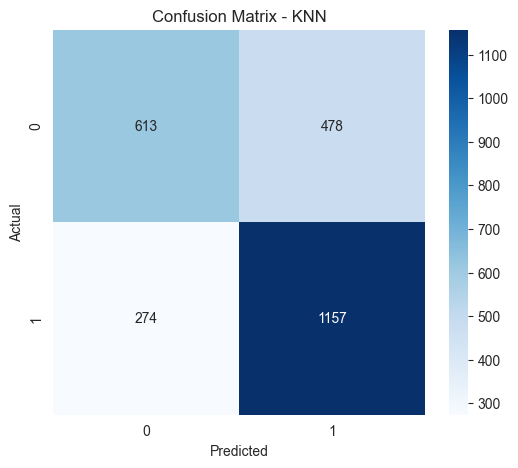

In [8]:
# Get the best model
best_knn = grid_search.best_estimator_

# Predictions
y_pred = best_knn.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 6. Visualization: K vs Accuracy (Simple simplified run)

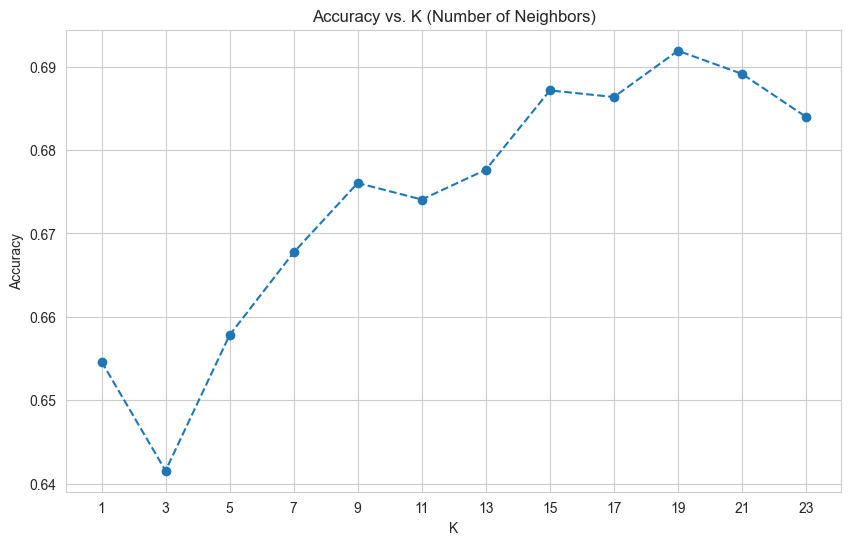

In [9]:
# Let's visualize how accuracy changes with K (using uniform weights for simplicity in plot)
# We will use the already preprocessed training data for efficiency loop or just reuse pipeline

k_values = range(1, 25, 2)
acc_scores = []

for k in k_values:
    # Re-instantiate pipeline with specific K
    temp_clf = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', KNeighborsClassifier(n_neighbors=k))])
    temp_clf.fit(X_train, y_train)
    acc = temp_clf.score(X_test, y_test)
    acc_scores.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(k_values, acc_scores, marker='o', linestyle='dashed')
plt.title('Accuracy vs. K (Number of Neighbors)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(list(k_values))
plt.show()